# Disease Classification: Dengue / Chikungunya / Other
### Models: CatBoost · RandomForest · LogisticRegression · HistGradientBoosting

## 1. Imports & Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import optuna
from optuna.distributions import FloatDistribution, IntDistribution, CategoricalDistribution

from optuna_integration import OptunaSearchCV
from sklearn.metrics import make_scorer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

RANDOM_STATE = 42
print('All libraries loaded.')

All libraries loaded.


## 2. Load Data & EDA

In [ ]:
df = pd.read_csv('./recife_fin.csv')
df.drop(columns=['race_color', 'is_pregnant', 
                 'female_x_pregnancy', 'leukopenia', 
                 'hematologic_disease', 'total_symptom_burden'], inplace=True)
print(f'Shape: {df.shape}')
df.head()

Shape: (75745, 53)


,age,sex,pregnancy_status,rash,arthralgia,arthritis,autoimmune_disease,back_pain,conjunctivitis,diabetes,...,dengue_warning_time_x_petechiae,age_x_arthritis,epidemic_season,days_from_peak_season,quarter_sin,quarter_cos,high_risk_age,metabolic_comorbidity_score,immunocompromised_flag,target_3class
0,0.5,Male,Not_applicable,0,0,0,0,0,0,0,...,0,0.0,0.0,161.0,-2.449294e-16,1.000000e+00,1,0,0,Other
1,20.0,Male,Not_applicable,0,0,0,0,0,0,0,...,0,0.0,0.0,176.0,1.000000e+00,6.123234e-17,0,0,0,Dengue
2,38.0,Female,Unknown,0,0,0,0,0,0,0,...,0,0.0,0.0,174.0,1.000000e+00,6.123234e-17,0,0,0,Other
3,23.0,Female,Unknown,0,0,0,0,0,0,0,...,0,0.0,0.0,176.0,1.000000e+00,6.123234e-17,0,0,0,Dengue
4,44.0,Female,Unknown,0,0,0,0,0,0,0,...,0,0.0,0.0,179.0,1.000000e+00,6.123234e-17,0,0,0,Dengue


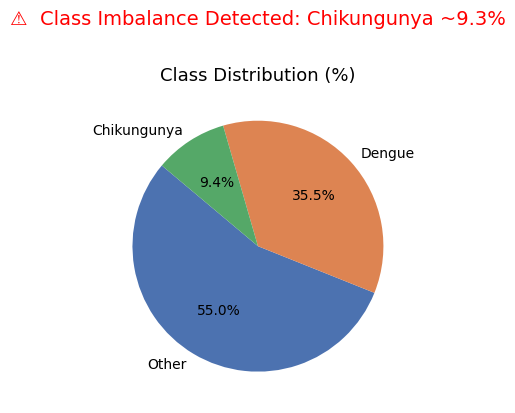

Class counts:
target_3class
Other          41351
Dengue         26703
Chikungunya     7068
Name: count, dtype: int64

Class percentages:
target_3class
Other          55.05
Dengue         35.55
Chikungunya     9.41
Name: count, dtype: float64


In [11]:
# Target distribution
fig, ax = plt.subplots(figsize=(12, 4))

vc = df['target_3class'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']

ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
ax.set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('⚠️  Class Imbalance Detected: Chikungunya ~9.3%', fontsize=14, color='red', y=1.02)
plt.tight_layout()
plt.show()

print('Class counts:')
print(vc)
print()
print('Class percentages:')
print((vc / vc.sum() * 100).round(2))

Columns with missing values: 14


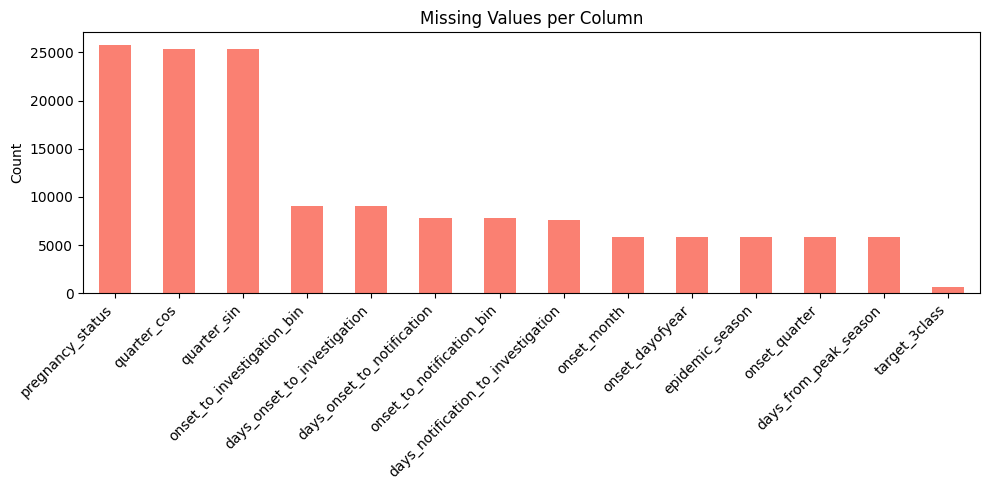

In [12]:
# Missing values heatmap
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='salmon')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [13]:
# Drop rows with missing target
df = df.dropna(subset=['target_3class'])
print(f'After dropping missing targets: {df.shape}')

# Separate features and target
X = df.drop(columns=['target_3class'])
y = df['target_3class']

# Identify column types
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns ({len(num_cols)}): {len(num_cols)} features')

After dropping missing targets: (75122, 53)
Categorical columns (4): ['sex', 'pregnancy_status', 'onset_to_investigation_bin', 'onset_to_notification_bin']
Numeric columns (48): 48 features


In [14]:
# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes:', le.classes_)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Classes: ['Chikungunya' 'Dengue' 'Other']
Train size: (60097, 52), Test size: (15025, 52)


In [15]:
# Helper: evaluate and visualise a fitted model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, classes):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    bal_acc = balanced_accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')

    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}')
    print(f'  Macro F1          : {macro_f1:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=classes))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nBalanced Acc: {bal_acc:.3f}  |  Macro F1: {macro_f1:.3f}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {'model': name, 'balanced_acc': bal_acc, 'macro_f1': macro_f1}

results = []
print('Helper ready.')

Helper ready.


## Model singularity + OptunaSearchCV

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_macro = make_scorer(f1_score, average='macro')

## 4. Model 1 — CatBoost
Handles categoricals natively and supports `class_weights` for imbalance.

In [ ]:
X_train_cb = X_train.copy()
X_test_cb  = X_test.copy()

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# Impute numerics
for col in num_cols:
    med = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(med)
    X_test_cb[col]  = X_test_cb[col].fillna(med)

# Impute categoricals
for col in cat_cols:
    m = X_train_cb[col].mode(dropna=True)
    mode = m.iloc[0] if not m.empty else "Missing"
    X_train_cb[col] = X_train_cb[col].fillna(mode).astype(str)
    X_test_cb[col]  = X_test_cb[col].fillna(mode).astype(str)

cat_features = cat_cols   # names are safer than column indices

catboost_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=RANDOM_STATE,
    verbose=0
)

cb_param_distributions = {
    'iterations': IntDistribution(200, 1000, step=100),
    'learning_rate': FloatDistribution(1e-2, 0.3, log=True),
    'depth': IntDistribution(4, 10),
    'l2_leaf_reg': FloatDistribution(1.0, 20.0, log=True),
    'random_strength': FloatDistribution(1e-3, 10.0, log=True),
    'border_count': IntDistribution(32, 255),
}

cb_search = OptunaSearchCV(
    estimator=catboost_model,
    param_distributions=cb_param_distributions,
    cv=cv,
    scoring=f1_macro,
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True
)

cb_search.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

print("CatBoost best score:", cb_search.best_score_)
print("CatBoost best params:", cb_search.best_params_)

catboost_best = cb_search.best_estimator_
catboost_best.fit(X_train_cb, y_train, cat_features=cat_features, class_weights=class_weights)

res = evaluate_model(
    'CatBoost (Optuna)',
    catboost_best,
    X_train_cb, y_train,
    X_test_cb, y_test,
    le.classes_,
)
results.append(res)

[I 2026-04-18 11:26:40,947] A new study created in memory with name: no-name-03c5551e-d8c9-4723-bcbb-87147602087d
[I 2026-04-18 11:30:31,053] Trial 0 finished with value: 0.5762709111020544 and parameters: {'iterations': 600, 'learning_rate': 0.16978466899414782, 'depth': 4, 'l2_leaf_reg': 2.603816985051009, 'random_strength': 0.08724665231224338, 'border_count': 98}. Best is trial 0 with value: 0.5762709111020544.
[I 2026-04-18 11:32:45,473] Trial 1 finished with value: 0.5161178161425335 and parameters: {'iterations': 300, 'learning_rate': 0.017632151084439954, 'depth': 5, 'l2_leaf_reg': 2.596790516319015, 'random_strength': 0.02490408860579169, 'border_count': 255}. Best is trial 0 with value: 0.5762709111020544.
[I 2026-04-18 11:37:30,643] Trial 2 finished with value: 0.5523902302208049 and parameters: {'iterations': 600, 'learning_rate': 0.022395750019237465, 'depth': 6, 'l2_leaf_reg': 4.1214040561418335, 'random_strength': 2.6783770815687205, 'border_count': 250}. Best is trial 0

In [ ]:
# Preprocessor for sklearn models (RF, LR, HGB)
# Numeric: median impute
# Categorical: most_frequent impute + label encode (ordinal)
from sklearn.preprocessing import OrdinalEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Preprocessor ready.')

Preprocessor ready.


## 5. Model 2 — Random Forest
Uses `class_weight='balanced_subsample'` to address imbalance at each bootstrap.

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_param = {
    'classifier__n_estimators': IntDistribution(200, 1000, step=100),
    'classifier__max_depth': IntDistribution(3, 20),
    'classifier__min_samples_split': IntDistribution(2, 20),
    'classifier__min_samples_leaf': IntDistribution(1, 10),
    'classifier__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'classifier__class_weight': CategoricalDistribution(['balanced', 'balanced_subsample', None]),
    'classifier__criterion': CategoricalDistribution(['gini', 'entropy'])
}

rf_search = OptunaSearchCV(
    estimator = rf_pipeline,
    param_distributions=rf_param,
    cv=cv,
    scoring=f1_macro,
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_search.fit(X_train, y_train)
print("RF best score:", rf_search.best_score_)
print("RF best params:", rf_search.best_params_)

rf_best = rf_search.best_estimator_

res = evaluate_model(
    'Random Forest',
    rf_best,
    X_train, y_train,
    X_test,  y_test,
    le.classes_
)
results.append(res)

[I 2026-04-17 21:13:10,108] A new study created in memory with name: no-name-60fa1fba-dfa3-490a-8f1b-6ae48d6e67c8


[I 2026-04-17 21:20:00,023] Trial 8 finished with value: 0.574443631534032 and parameters: {'classifier__n_estimators': 200, 'classifier__max_depth': 20, 'classifier__min_samples_split': 6, 'classifier__min_samples_leaf': 9, 'classifier__max_features': 'log2', 'classifier__class_weight': None, 'classifier__criterion': 'gini'}. Best is trial 8 with value: 0.574443631534032.
[I 2026-04-17 21:20:50,945] Trial 3 finished with value: 0.6018463149924644 and parameters: {'classifier__n_estimators': 200, 'classifier__max_depth': 17, 'classifier__min_samples_split': 9, 'classifier__min_samples_leaf': 8, 'classifier__max_features': None, 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}. Best is trial 3 with value: 0.6018463149924644.
[I 2026-04-17 21:21:28,514] Trial 5 finished with value: 0.5627608436508093 and parameters: {'classifier__n_estimators': 200, 'classifier__max_depth': 10, 'classifier__min_samples_split': 7, 'classifier__min_samples_leaf': 2, 'classifier__max

## 6. Model 3 — Logistic Regression
Rows with **any** missing value are dropped before training (no imputation). Uses `class_weight='balanced'` and L2 regularisation; scaled features for best convergence.

Rows after dropping any NaN: 32,334  (removed 42,788 rows)
No missing values remain — confirmed.
LR Train: (25867, 58)  |  LR Test: (6467, 58)

  Logistic Regression
  Balanced Accuracy : 0.5567
  Macro F1          : 0.4894

              precision    recall  f1-score   support

 Chikungunya       0.28      0.72      0.41       784
      Dengue       0.57      0.40      0.47      2795
       Other       0.63      0.55      0.59      2888

    accuracy                           0.51      6467
   macro avg       0.50      0.56      0.49      6467
weighted avg       0.56      0.51      0.52      6467



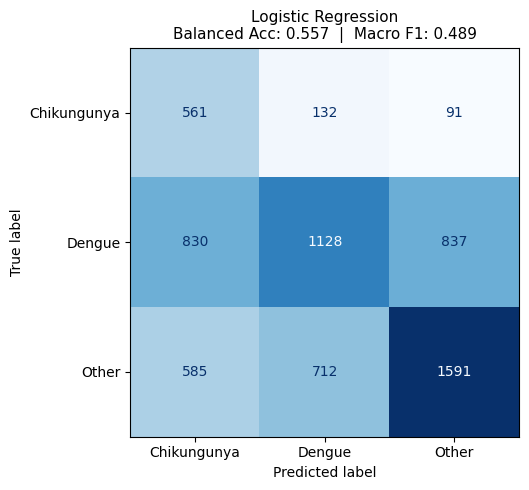

In [ ]:
# --- Drop ALL rows that contain any missing value ---
df_lr = df.dropna()   # df already has missing targets removed (from Section 3)
print(f'Rows after dropping any NaN: {len(df_lr):,}  '
      f'(removed {len(df) - len(df_lr):,} rows)')

X_lr = df_lr.drop(columns=['target_3class'])
y_lr = le.transform(df_lr['target_3class'])   # reuse fitted LabelEncoder

# Verify no NaNs remain
assert X_lr.isnull().sum().sum() == 0, 'NaNs still present!'
print('No missing values remain — confirmed.')

# Stratified split on the clean subset
X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_lr
)
print(f'LR Train: {X_lr_train.shape}  |  LR Test: {X_lr_test.shape}')

# Preprocessor with NO imputer (data is already clean)
from sklearn.preprocessing import OrdinalEncoder

lr_cat_cols = X_lr.select_dtypes(include=['object', 'string']).columns.tolist()
lr_num_cols = X_lr.select_dtypes(include=['number']).columns.tolist()

lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        C=1.0,
        penalty='l2',
        class_weight='balanced',    # handles imbalance
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE,
    ))
])

res = evaluate_model(
    'Logistic Regression',
    lr_pipeline,
    X_lr_train, y_lr_train,
    X_lr_test,  y_lr_test,
    le.classes_
)
results.append(res)

## 7. Model 4 — HistGradientBoosting
Natively supports missing values. Class weights applied via `class_weight`.

In [ ]:
# HistGradientBoosting handles NaN natively for numerics,
# but categoricals still need encoding
from sklearn.preprocessing import OrdinalEncoder as OE

hgb_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OE(handle_unknown='use_encoded_value', unknown_value=-1))
])

hgb_preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),  # no scaling needed for HGB
    ('cat', hgb_cat_transformer, cat_cols)
])

# Compute class weights manually
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
hgb_w = np.array([cw[c] for c in y_train])

hgb_model = Pipeline([
    ('preprocessor', hgb_preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        early_stopping=True
    ))
])

hgb_param_distributions = {
    'classifier__learning_rate': FloatDistribution(1e-2, 0.2, log=True),
    'classifier__max_iter': IntDistribution(100, 600, step=50),
    'classifier__max_depth': IntDistribution(3, 12),
    'classifier__max_leaf_nodes': IntDistribution(15, 63),
    'classifier__min_samples_leaf': IntDistribution(10, 100, step=5),
    'classifier__l2_regularization': FloatDistribution(1e-6, 10.0, log=True),
    'classifier__max_bins': IntDistribution(64, 255),
    'classifier__class_weight': CategoricalDistribution([None, 'balanced', hgb_w])
}

hgb_search = OptunaSearchCV(
    estimator=hgb_model,
    param_distributions=hgb_param_distributions,
    cv=cv,
    scoring=f1_macro,
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

hgb_search.fit(X_train, y_train)

print("HGB best score:", hgb_search.best_score_)
print("HGB best params:", hgb_search.best_params_)

hgb_best = hgb_search.best_estimator_

res = evaluate_model(
    'HistGradientBoosting (Optuna)',
    hgb_best,
    X_train, y_train,
    X_test, y_test,
    le.classes_
)
results.append(res)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## 8. Model Comparison

                      balanced_acc  macro_f1
model                                       
Random Forest             0.623127  0.609017
HistGradientBoosting      0.655991  0.590135
CatBoost                  0.655222  0.579524
Logistic Regression       0.556680  0.489424


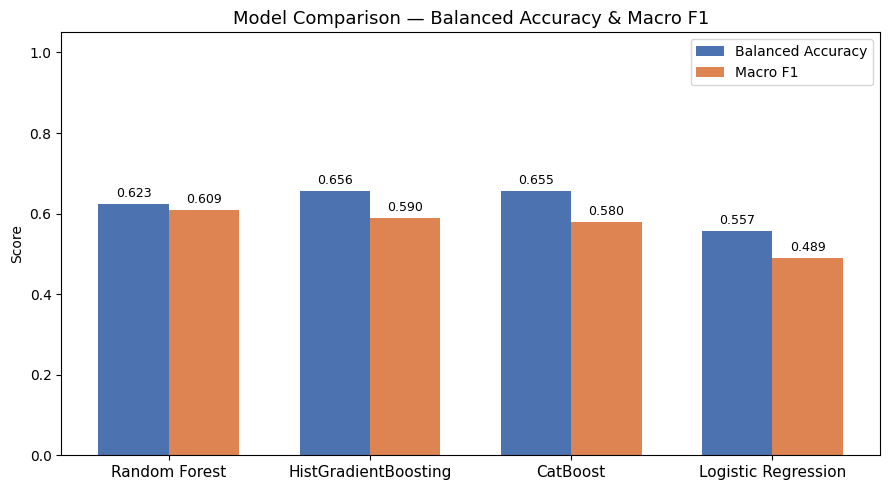


🏆 Best model by Macro F1: Random Forest


In [ ]:
results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
results_df = results_df.set_index('model')
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['balanced_acc'], width,
               label='Balanced Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, results_df['macro_f1'], width,
               label='Macro F1', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Balanced Accuracy & Macro F1', fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best = results_df['macro_f1'].idxmax()
print(f'\n🏆 Best model by Macro F1: {best}')

## 9. Feature Importance (CatBoost & Random Forest)

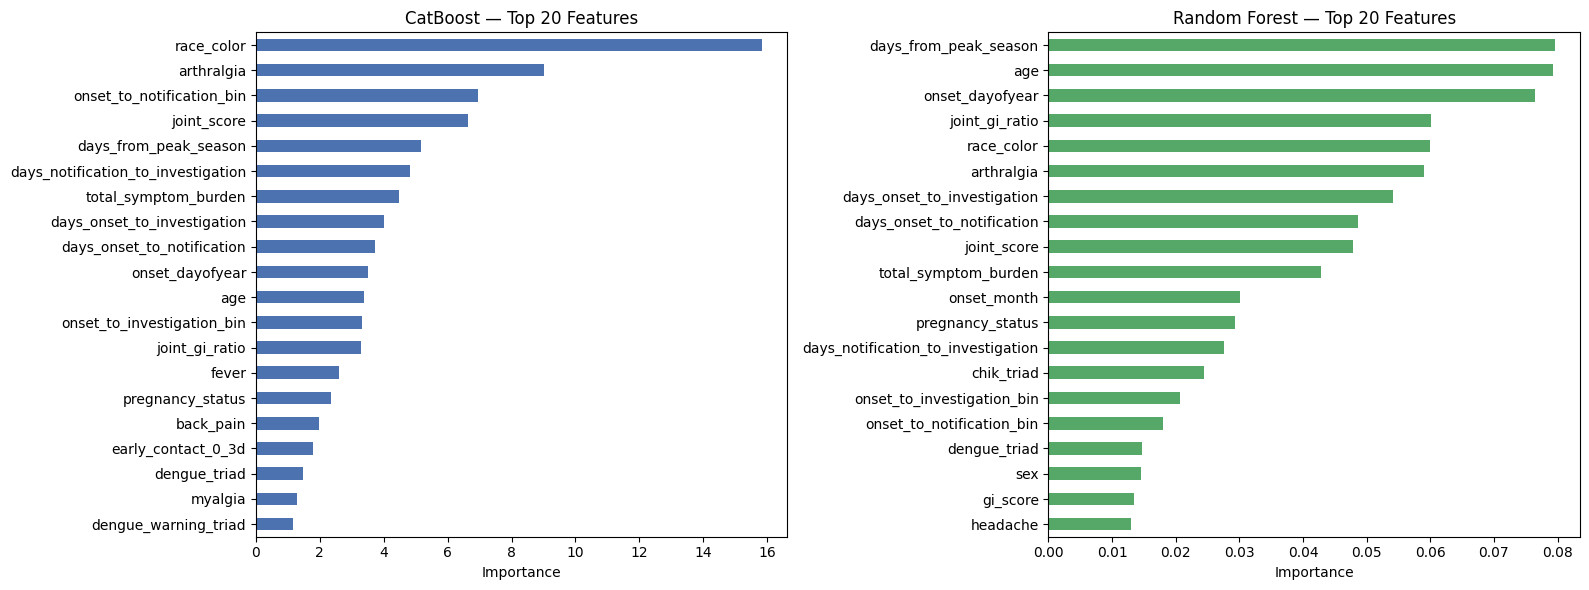

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CatBoost feature importance
cb_fi = pd.Series(
    catboost_model.get_feature_importance(),
    index=X_train_cb.columns
).sort_values(ascending=False).head(20)

cb_fi.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('CatBoost — Top 20 Features', fontsize=12)
axes[0].set_xlabel('Importance')

# Random Forest feature importance
rf_fi = pd.Series(
    rf_pipeline.named_steps['classifier'].feature_importances_,
    index=num_cols + cat_cols
).sort_values(ascending=False).head(20)

rf_fi.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].invert_yaxis()
axes[1].set_title('Random Forest — Top 20 Features', fontsize=12)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Conclusions
### 1. This is not simply a linear-problem (or at least the overall dataset).
Using Tree-based algorithm would suit better.
Unless we can divide the dataset into a linear subcategory, a multi-polynomial or conditional subcategory, using **XGBoost**, **HistGradientBoosting** and **CatBoost** would be the best.

### 2. race priority problem?
Since we are Yellow-skinned, race really affects the prediction for Vietnamese people. Really consider dropping it.

### 3. 

In [ ]:
sinan = pd.read_csv(r'C:\Users\Quoc Thai\Downloads\ML\HealthcareSystemForDengueFever\dataset\raw\Chikukunya\sinan-db.csv')
recife = pd.read_csv(r'C:\Users\Quoc Thai\Downloads\ML\HealthcareSystemForDengueFever\dataset\raw\Chikukunya\recife-db.csv')
sinan.head()

,Unnamed: 0,NU_NOTIFIC,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,...,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H,CS_FLXRET,FLXRECEBI,IDENT_MICR,MIGRADO_W
0,0,50375,2,A90,1/6/2015,201522,2015,13,130040,5584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
1,1,50398,2,A90,8/6/2015,201523,2015,13,130040,5584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
2,2,50381,2,A90,8/6/2015,201523,2015,13,130040,5584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
3,3,50352,2,A90,11/5/2015,201519,2015,13,130040,5584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
4,4,50328,2,A90,11/5/2015,201519,2015,13,130040,5584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN


In [ ]:
recife.head()

,Unnamed: 0,nu_notificacao,tp_notificacao,co_cid,dt_notificacao,ds_semana_notificacao,notificacao_ano,co_uf_notificacao,co_municipio_notificacao,id_regional,...,gengivo,metro,petequias,hematura,sangram,laco_n,plasmatico,evidencia,plaq_menor,complica
0,0,2126258,2.0,A90,2015-12-10,201549.0,2015.0,26.0,261160.0,1497.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1562314,2.0,A90,2015-01-21,201503.0,2015.0,26.0,261160.0,1497.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1758636,2.0,A90,2015-01-06,201501.0,2015.0,26.0,260960.0,1497.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2127412,2.0,A90,2015-10-26,201543.0,2015.0,26.0,261160.0,1497.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1562589,2.0,A90,2015-01-19,201503.0,2015.0,26.0,261160.0,1497.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
